In [1]:
import matplotlib.pyplot as plt
import os
import numpy as np
import tidy3d as td
import sys
from scipy.integrate import simpson
from scipy.ndimage import uniform_filter1d
# Assuming /AutomationModule is in the root directory of your project
sys.path.append(os.path.abspath(rf'../../../../../tidy3d'))

from AutomationModule import * 

import AutomationModule as AM

plt.rc('font', family='Arial')

In [2]:
# data = AM.read_hdf5_as_dict("./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90.h5")
data = AM.read_hdf5_as_dict("./data/L_1_12x/field_data_12x_raw_field_Ex_Ey_Ez_L_1_ff_0p2237_n_2p90_absorbers.h5")
data_ls = AM.read_hdf5_as_dict(r"../20251002_Ls_test/data/ls_values/20260608_ls_values_n_2p9.h5")

In [3]:
data_g = AM.read_hdf5_as_dict(r"../data/g_values/n_2.90_ff_0.2237_g_data.h5")
data_g.keys()

dict_keys(['ff', 'g', 'n', 'nu'])

In [4]:
gap_data = AM.read_hdf5_as_dict(rf"../../20250630 MPB Bands analysis/Data/gap_data.hdf5")
gaps_ff_22_n_2p90=14.3/(gap_data["Circular"]["0.22"]["gap_edges"][np.where(gap_data["Circular"]["0.22"]["n"]==2.9)[0]]).flatten()

In [5]:
data.keys()

dict_keys(['2.90'])

In [6]:
a=2.562629142772549

In [7]:
def diameter(intensity_array, x, y):
    """Participation-ratio beam diameter d = 2 sqrt(A_eff / pi), with the
    effective area A_eff = (int I dx dy)^2 / int I^2 dx dy.

    Scale-invariant in I (any global normalisation cancels), and robust to the
    faint diffuse background that dominates the raw second moment <rho^2> on
    single-shot data. NOTE: on a single speckle realisation it is biased LOW by
    sqrt(<I^2>/<I>^2) relative to the smooth ensemble-mean profile (~sqrt(4/3),
    i.e. ~15%, for the 3-component intensity sum; up to sqrt(2) if one
    polarisation dominates) -- see the nu-window averaged d_avg below for the
    speckle-mitigated estimate. Works on (nx, ny) or (nx, ny, nfreq) arrays."""
    intensity = intensity_array
    integral_1 = simpson(simpson(intensity**2, x=y, axis=1), x=x, axis=0)
    integral_2 = simpson(simpson(intensity, x=y, axis=1), x=x, axis=0)**2

    return 2*np.sqrt((integral_2/integral_1)/np.pi)

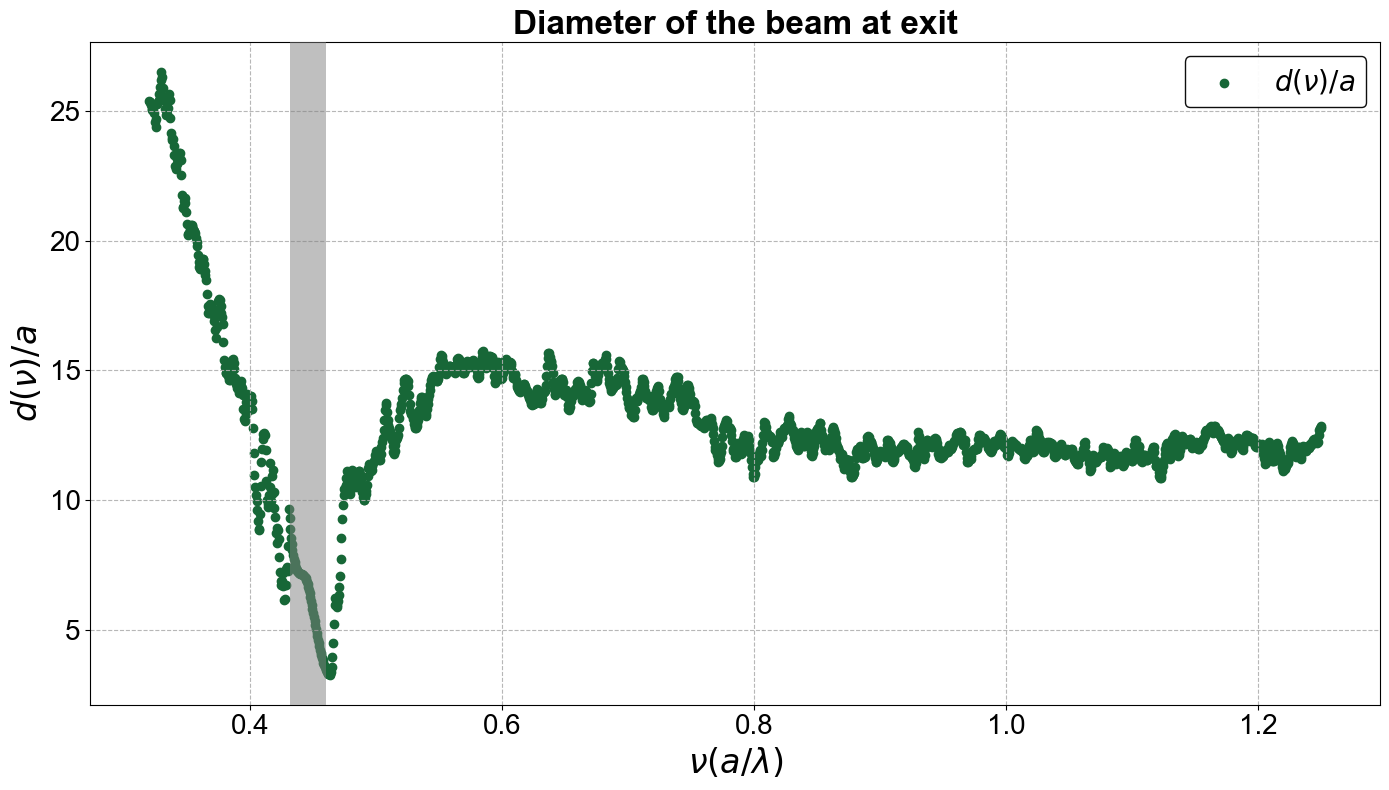

In [8]:
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

for k,key in enumerate(data.keys()):
    intensity_values = ((np.abs(data[key]["Ex"])**2 + np.abs(data[key]["Ey"])**2 + np.abs(data[key]["Ez"])**2).squeeze())
    intensity_values = intensity_values/np.max(intensity_values)

    d = diameter(intensity_values,data[key]["x"],data[key]["y"])/a
    freq = a*data[key]["f"]/(td.C_0)
    ax.scatter(freq,d,label=rf"$d(\nu)/a$")
    

ax.set_xlabel(rf"$\nu (a/\lambda)$", fontsize=24, fontweight='bold')
ax.set_ylabel(rf"$d(\nu)/a$", fontsize=24, fontweight='bold')
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.legend(loc='best', fontsize=20, framealpha=0.95, edgecolor='black')

# Improve tick label size
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_title(rf"Diameter of the beam at exit", fontsize=24, fontweight='bold')
ax.axvspan(a/gaps_ff_22_n_2p90[0], a/gaps_ff_22_n_2p90[1], facecolor='gray', alpha=0.5, edgecolor='none', zorder=1000, clip_on=False)

# Add subtle background
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()


## Expected spreading in a diffusive slab *without absorption*

We want a baseline that says: *if the light merely diffused (multiple scattering, no localization, no absorption), how wide would the transmitted beam be at each frequency?* Any measured width **below** that baseline signals (sub‑diffusive) transverse confinement.

### Steady‑state width vs. frequency $d(\nu)$ — **this notebook**
A tightly focused beam transmitted through a slab of thickness $L$ produces a bell‑shaped, spatially‑resolved transmission $T(\rho)$ at the exit face. In the diffusion approximation ($\mu_a=0$, $k\ell^{*}\!\gg\!1$, $L\!\gg\!\ell^{*}$) its Hankel transform is, following **Cherroret, Skipetrov & van Tiggelen, *Phys. Rev. E* 82, 056603 (2010)** (the reference for this geometry),

$$ T(q)=\frac{\sinh(q\,\ell^{*})}{\sinh(q\,L)}\qquad\text{(their Eq. 3)} $$

and the **mean‑square width** $\sigma^{2}=\langle\rho^{2}\rangle=\int\rho^{2}T\,d^{2}\rho\big/\int T\,d^{2}\rho$ is

$$ \boxed{\;\sigma^{2}_{\rm dif}=\tfrac{2}{3}\,L^{2}\Big[1-\big(\ell^{*}/L\big)^{2}\Big]\;\xrightarrow{\ \ell^{*}\ll L\ }\;\tfrac{2}{3}L^{2}\;}\qquad\text{(their Eq. 4).} $$

The paper derives these with its (isotropic‑scattering) mean free path $\ell$; its discussion section explicitly endorses the substitution $\ell\to\ell^{*}$ (bare **transport** mfp, $\ell^{*}=\ell_s/(1-g)$) — *including in the source depth* $z'=\ell^{*}$ — for disorder with finite correlation length, provided $L\gg\ell^{*}$. That is what we use.

**Key physics — read this before "fixing" the flat shape:**

- $\sigma^{2}_{\rm dif}$ is set by the **slab thickness $L$** and is **independent of the diffusion constant** — hence of $\ell^{*}$ (up to the small $(\ell^{*}/L)^{2}$ term). *The diffusive baseline is therefore (nearly) **flat in $\nu$** — this is a feature, not a bug.* The paper states it explicitly: "*even a very small, but finite and spatially uniform diffusion coefficient would lead to the same result $\sigma^{2}=2L^{2}/3$.*" So the baseline is **not** supposed to track the measured $d(\nu)$.
- **Confinement narrows it**: $\sigma^{2}_{\rm loc}\simeq 2L\xi$ (their Table I, leading order for $\ell^{*}\!\ll\!\xi\!\ll\!L$; full expression = their Eq. 6), so the measured width dropping **below** the flat diffusive line is the transverse‑confinement signature. **CW caveat (their pp. 7–8):** for strong absorption ($L_a\!\ll\!L$) the *same* calculation gives $\sigma^{2}\simeq 2LL_a$ — "*absorption plays exactly the same role as localization*", and a **stationary** measurement *cannot* tell them apart. Inside a photonic (pseudo)gap, Bragg/evanescent attenuation acts as exactly such an effective $L_a$. The gap dip therefore yields an **attenuation length** ($\xi$ *or* the Bragg decay length); attributing it to Anderson localization rests on the **time‑resolved $\sigma^{2}(t)$** (absorption‑immune, see below) and on thickness scaling — not on the CW dip alone.
- **Boundary internal reflection ($z_0$):** the paper sets $z_0=0$ and reports corrections $\mathcal{O}(z_0/L)$ ("virtually independent of $z_0$ *as long as $z_0\ll L$*"). With extrapolated boundaries $\sigma^{2}=\tfrac23\big[(L+2z_0)^2-(\ell^{*}+z_0)^2-3z_0^2\big]$, i.e. a relative shift $\approx+4z_0/L$. Here $\ell^{*}/L\simeq0.2$–$0.3$ across the comparison band and $z_0=\tfrac23\ell^{*}(1+\bar R)/(1-\bar R)\gtrsim\tfrac23\ell^{*}$ (Zhu–Pine–Weitz, ref. 6), so this is a **tens‑of‑percent (one‑sided, positive) systematic on $\sigma^{2}_{\rm dif}$**, not negligible. Since $z_0>0$ *raises* the baseline, it makes the gap dip **more** significant; the high‑$\nu$ agreement below should be read with this band in mind. (This closed form still replaces the earlier image‑dipole construction, which depended strongly on $A$, blew up as $\ell^{*}\!\to\!L$, and gave the *wrong* $\langle\rho^{2}\rangle$.)
- It is a **diffusion** result, valid only for $\ell^{*}<L$. At low $\nu$ where $\ell^{*}>L$ transport is quasi‑ballistic and the baseline is **undefined** (returned as `NaN`). The sampled baseline additionally applies $\ell^{*}\le0.3L$ — a **chosen tolerance** (the paper only requires $L\gg\ell^{*}$; at the cut $L=3.3\,\ell^{*}$ and the $z_0$ systematic peaks), not a number from the paper.
- **Mobility‑edge benchmark**: at $k\ell^{*}=1$ the paper finds $\sigma^{2}_{\rm ME}=\tfrac38L^{2}(1+4z_c/L)$, $z_c\simeq3\ell^{*}$ (their Eq. 8 / Table I) — the natural crossover reference between diffuse ($\tfrac23L^2$) and localized ($2L\xi$); available as `sigma2_mobility_edge_cw`.

**How the curves are made comparable.** The simulated $d(\nu)$ is a single‑realization speckle measured with the participation‑ratio `diameter()` estimator (robust to the faint diffuse background, unlike the second moment $\sigma^{2}$, which is background‑dominated on single shots). To compare like‑for‑like we build $T(\rho)$ from Eq. (3) and pass it through the **same** `diameter()` estimator; because $T(\rho)$ has exponential (not algebraic) tails this is well defined and grid‑independent. One residual estimator mismatch remains: the theory profile is the smooth *ensemble mean*, while the PR estimator on a single speckle realization reads low by $\sqrt{\langle I^{2}\rangle/\langle I\rangle^{2}}$ ($\approx\sqrt{4/3}\simeq1.15$ for the 3‑component sum). We therefore also show $d_{\rm avg}(\nu)$, computed after incoherently averaging $I$ over a small $\nu$ window (a surrogate ensemble average); it raises the high‑$\nu$ width by $\sim5\%$, as expected for this bias. With **no free parameters** (only $L$ and the measured $\ell^{*}(\nu)$): across the clean diffusive band ($\nu\ge0.8$, where $\ell^{*}/L\simeq0.19$–$0.30$) the raw $d$ sits a median **6 % above** $d_{\rm dif}$ (range −2 % to +15 %; e.g. $11.9$ vs $11.3$ at $\nu=0.9$; $\nu$‑averaged: $12.6$, ≈ +11 %) — note the $z_0$ (theory **up**) and speckle (data **down**) systematics partially cancel here, so the few‑percent agreement is partly fortuitous. Inside the gap the measured curve plunges to $d\approx4.0$ ($\nu$‑avg $3.9$) against a baseline of $11.6$ — a factor ≈ 3 below, far outside every systematic above. Just above the gap ($\nu\approx0.66$–$0.70$) the data runs ~30–40 % **above** the baseline — band‑edge transport enhancement, not confinement. The robust, physical content is the flat **shape** of $d_{\rm dif}$ and the data's **departure** from it (the gap dip). The closed‑form RMS width is also available as `sigma2_diffusive_cw` for a metric‑independent check.

### Time‑resolved counterpart (folder `20251007_Beam_Spreading`, FFT notebook)
For a short pulse the transverse mean‑square width grows as $\sigma^{2}(t)=4Dt$ in the diffuse regime ($D=\tfrac13 v_E\ell^{*}$, with the paper's weak‑localization refinement $D\simeq D_B[1-(k\ell^{*})^{-2}]$) and **saturates at $\sigma^{2}_{\infty}\simeq 2L\xi(1-\xi/L)$** under localization (Cherroret 2010; Sperling 2013). Crucially $\sigma^{2}(t)$ is **insensitive to absorption** — in an absorbing but diffusive medium it keeps growing linearly — removing the Scheffold–Wiersma–Maret ambiguity that limits the CW dip above. Implemented here as `diffusive_width_time(t, D)`.

### References
1. **N. Cherroret, S. E. Skipetrov, B. A. van Tiggelen**, *Transverse confinement of waves in three‑dimensional random media*, **Phys. Rev. E 82, 056603 (2010)** — $T(q)=\sinh(q\ell)/\sinh(qL)$, $\sigma^{2}_{\rm dif}=\tfrac23L^2[1-(\ell/L)^2]$, $\sigma^{2}_{\rm loc}\simeq2L\xi$, $\sigma^{2}_{\rm ME}=\tfrac38L^2$; CW localization/absorption equivalence ($\sigma^2\simeq2LL_a$); the steady‑state and pulsed transverse‑confinement theory used here.
2. **H. Hu, A. Strybulevych, J. H. Page, S. E. Skipetrov, B. A. van Tiggelen**, *Localization of ultrasound in a three‑dimensional elastic network*, **Nat. Phys. 4, 945 (2008)** — the 3D transverse‑confinement experiment ($\sigma^2$ as the localization probe).
3. **T. Sperling, W. Bührer, C. M. Aegerter, G. Maret**, *Direct determination of the transition to localization of light in three dimensions*, **Nat. Photon. 7, 48 (2013)** — $\sigma^{2}(t)=4Dt$ growth / saturation as the localization probe.
4. **H. De Raedt, A. Lagendijk, P. de Vries**, *Transverse localization of light*, **PRL 62, 47 (1989)**; **T. Schwartz, G. Bartal, S. Fishman, M. Segev**, *Transport and Anderson localization in disordered 2D photonic lattices*, **Nature 446, 52 (2007)** — the transverse‑localization geometry (propagation axis ↔ time).
5. **F. Scheffold, R. Lenke, R. Tweer, G. Maret**, *Localization or classical diffusion of light?*, **Nature 398, 206 (1999)** — absorption can mimic the stationary localization signature (motivates the no‑absorption / pulsed baseline).
6. **J. X. Zhu, D. J. Pine, D. A. Weitz**, *Internal reflection of diffusive light in random media*, **PRA 44, 3948 (1991)** — extrapolation length / internal reflection $z_0$ (sets the size of the $+4z_0/L$ baseline systematic quoted above).

In [9]:
# =====================================================================
#  Expected transverse spreading in a NON-ABSORBING diffusive slab
#  Cherroret, Skipetrov & van Tiggelen, Phys. Rev. E 82, 056603 (2010)
# =====================================================================
# A tightly focused beam transmitted through a slab of thickness L produces a
# bell-shaped, spatially-resolved transmission T(rho) at the exit face. In the
# diffusion approximation (mu_a = 0, k l* >> 1, L >> l*) its Hankel transform is
#
#       T(q) = sinh(q l*) / sinh(q L)                          (Cherroret Eq. 3)
#
# (the paper's l -> bare transport mfp l*; the substitution, including in the
# source depth z' = l*, is explicitly endorsed in their discussion section for
# correlated disorder, provided L >> l*), and the mean-square width
# sigma^2 = <rho^2> = int rho^2 T / int T is
#
#       sigma^2_dif = (2/3) L^2 [1 - (l*/L)^2]   ->  2 L^2 / 3  (Cherroret Eq. 4)
#
# KEY PHYSICS:
#  * sigma^2_dif is set by the slab THICKNESS L and is INDEPENDENT of the
#    diffusion constant (hence of l*, up to the small (l*/L)^2 term): the
#    diffusive baseline is (nearly) FLAT in nu -- a feature, not a bug.
#    Confinement narrows it to sigma^2_loc ~ 2 L xi (Table I).
#  * CW CAVEAT (paper pp. 7-8): a stationary sigma^2 CANNOT distinguish
#    localization from absorption/attenuation -- for L_a << L they derive
#    sigma^2 ~ 2 L L_a, the SAME form as 2 L xi. In-gap Bragg/evanescent decay
#    plays exactly this role, so the gap dip alone yields an attenuation
#    length (xi OR Bragg L_B); attribution to localization rests on the
#    absorption-immune time-resolved sigma^2(t) and on L-scaling.
#  * z0 / internal reflection: the paper sets z0 = 0 and quotes corrections
#    O(z0/L) ("virtually independent of z0 AS LONG AS z0 << L"). With
#    extrapolated boundaries sigma^2 = (2/3)[(L+2z0)^2 - (l*+z0)^2 - 3 z0^2],
#    a relative shift ~ +4 z0/L. With l*/L ~ 0.2-0.3 here and z0 >= (2/3) l*
#    (larger with internal reflections, Zhu-Pine-Weitz), that is a
#    tens-of-percent one-sided systematic: z0 > 0 RAISES the baseline (gap dip
#    becomes MORE significant). This closed form replaces the earlier
#    image-dipole construction, which depended strongly on A, blew up as
#    l* -> L, and gave the WRONG <rho^2>.
#  * Diffusion result: valid only for l* < L; NaN otherwise (e.g. low nu,
#    where l* > L and transport is quasi-ballistic). The sampled baseline in
#    the next cell additionally applies l* <= 0.3 L -- a CHOSEN tolerance, not
#    a number from the paper (which only requires L >> l*).
#
# We build T(rho) from Eq. 3 (Hankel transform) and pass it through the SAME
# participation-ratio diameter() estimator used on the simulated field, so the
# theory and data curves are measured identically. T(rho) has exponential (not
# algebraic) tails, so the estimate is well defined and grid-independent.
from scipy.special import j0


def diffusive_profile_cw(x, y, L, l_tr, n_q=3000, n_r=1500, center=(0.0, 0.0)):
    """CW transmitted intensity profile T(x, y) of a non-absorbing diffusive slab
    of thickness ``L`` with transport mean free path ``l_tr`` (Cherroret 2010,
    Eq. 3):  T(q)=sinh(q l*)/sinh(q L),  T(rho)=(1/2pi) int T(q) J0(q rho) q dq.
    (Utility for profile inspection; the comparison below uses
    ``diffusive_diameter_cw``, which shares the same kernel.)

    Returns a peak-normalised 2D array (axis 0 -> x, axis 1 -> y), or an all-NaN
    array if l_tr >= L (diffusion approximation invalid)."""
    X, Y = np.meshgrid(np.asarray(x, float), np.asarray(y, float), indexing="ij")
    rho = np.sqrt((X - center[0]) ** 2 + (Y - center[1]) ** 2)
    if not (0.0 < l_tr < L):
        return np.full_like(rho, np.nan)
    q = np.linspace(1e-6, 40.0 / L, n_q)            # T(q) ~ exp(-q (L - l*))
    Tq = np.sinh(q * l_tr) / np.sinh(q * L)
    r = np.linspace(0.0, float(rho.max()), n_r)     # radial profile via Hankel
    Tr = np.clip(j0(np.outer(r, q)) @ (Tq * q), 0.0, None)
    T = np.interp(rho.ravel(), r, Tr).reshape(rho.shape)
    peak = T.max()
    return T / peak if peak > 0 else T


def diffusive_diameter_cw(x, y, L, l_tr, a_norm=1.0, n_q=3000, n_r=1500, center=(0.0, 0.0)):
    """Diffusive beam diameter d/a_norm at the exit of a non-absorbing slab,
    measured with the SAME participation-ratio estimator as the field data
    (Cherroret 2010). The omitted 1/(2pi) and dq Hankel prefactors are pure
    scale factors that cancel in the scale-invariant estimator.

    ``l_tr`` may be a scalar or a 1D array (one value per frequency); NaN is
    returned where l_tr >= L. The Hankel kernel is built once and reused over the
    frequency loop for speed. NOTE: the q cutoff 40/L truncates T(q) at
    exp(-40 (1 - l*/L)) -- negligible (~e-28) for the l* <= 0.3 L mask used
    below, but raise it if that mask is ever relaxed toward l* -> L."""
    l_arr = np.atleast_1d(l_tr).astype(float)
    X, Y = np.meshgrid(np.asarray(x, float), np.asarray(y, float), indexing="ij")
    rho = np.sqrt((X - center[0]) ** 2 + (Y - center[1]) ** 2)
    rho_flat = rho.ravel()
    q = np.linspace(1e-6, 40.0 / L, n_q)
    r = np.linspace(0.0, float(rho.max()), n_r)
    kernel = j0(np.outer(r, q)) * q                  # (n_r, n_q), reused per freq
    out = np.full(l_arr.size, np.nan)
    for i, lt in enumerate(l_arr):
        if not (0.0 < lt < L):
            continue
        Tr = np.clip(kernel @ (np.sinh(q * lt) / np.sinh(q * L)), 0.0, None)
        T_rho = np.interp(rho_flat, r, Tr).reshape(rho.shape)
        peak = T_rho.max()
        if peak > 0:
            out[i] = (diameter(T_rho / peak, x, y) / a_norm)
    return out[0] if out.size == 1 else out


def sigma2_diffusive_cw(L, l_tr):
    """Closed-form mean-square width sigma^2 = <rho^2> of the diffusive transmitted
    beam (Cherroret 2010, Eq. 4):  (2/3) L^2 [1 - (l*/L)^2].  NaN for l* >= L.
    Independent of the diffusion constant. Derived with z0 = 0: boundary internal
    reflection shifts it by ~ +4 z0/L (one-sided, positive -- see header)."""
    l_tr = np.asarray(l_tr, float)
    return np.where(l_tr < L, (2.0 / 3.0) * L ** 2 * (1.0 - (l_tr / L) ** 2), np.nan)


def sigma2_localized_cw(L, xi):
    """Mean-square width in the localized regime (Cherroret 2010, Table I, leading
    order for l* << xi << L; their Eq. 6 has the subleading terms):
    sigma^2_loc ~ 2 L xi. CW CAVEAT: strong absorption (or in-gap Bragg decay)
    gives the identical form sigma^2 ~ 2 L L_a (paper pp. 7-8), so a CW fit
    yields an attenuation length, not necessarily xi -- disambiguate with the
    time-resolved sigma^2(t)."""
    return 2.0 * L * np.asarray(xi, float)


def sigma2_mobility_edge_cw(L, l_tr):
    """Mean-square width at the mobility edge k l* = 1 (Cherroret 2010, Eq. 8 /
    Table I):  sigma^2_ME = (3/8) L^2 (1 + 4 z_c / L), with z_c ~ 3 l* (their
    z0 = 0 value). The crossover reference between diffuse (2/3 L^2) and
    localized (2 L xi). A like-for-like diameter through ``diameter()`` would
    need the full T(q) of their Eqs. (7), (9)-(11); this is the sigma^2-level
    benchmark only."""
    z_c = 3.0 * np.asarray(l_tr, float)
    return (3.0 / 8.0) * L ** 2 * (1.0 + 4.0 * z_c / L)


def diffusion_constant(l_tr, v_E):
    """Boltzmann transport diffusion constant D = v_E * l* / 3 (3D medium; the
    transverse profile is its 2D cut, hence sigma^2(t) = 4 D t). The paper's
    diffuse-regime refinement is D ~ D_B [1 - (k l*)^-2] (weak localization)."""
    return v_E * l_tr / 3.0


def diffusive_width_time(t, D, w0=0.0):
    """Time-resolved diffusive transverse RMS width (no absorption, 2D plane):
    w(t) = sqrt(w0**2 + 4 D t)  (Cherroret 2010: sigma^2(t)=4Dt in the diffuse
    regime, saturating at ~2 L xi (1 - xi/L) under localization; insensitive to
    absorption -- the absorption-proof localization probe, unlike the CW dip).
    Benchmark for the time-domain notebooks (20251007_Beam_Spreading,
    20260602_IPR_Calculation_FFT)."""
    return np.sqrt(w0 ** 2 + 4.0 * D * t)

In [ ]:
# --- Diffusive (no-absorption) benchmark vs the measured d(nu) ----------------
# Cherroret 2010 diffusive transverse width, built into a T(rho) profile and
# measured with the SAME diameter() estimator as the field data. It is nearly
# flat in nu (set by L, not l*) and is defined only where l* < L; the measured
# d(nu) dropping BELOW it (e.g. inside the gap) is the confinement signature
# (localization OR gap attenuation -- CW cannot tell, see markdown above).

L_slab = 14.3          # slab thickness in um  (= t_slab_z of the run, box_size*scaling)
x_, y_ = data["2.90"]["x"], data["2.90"]["y"]
freq = a * data["2.90"]["f"] / td.C_0                  # ascending 0.32 -> 1.25

ls = np.asarray(data_ls["0.2237"], dtype=float)        # um, aligned to ascending freq
# data_g['g'] is already in ascending-frequency order (same ordering as ls and
# freq); only the companion data_g['nu'] axis is stored reversed in this file, so
# it is NOT used here to reorder g. Pair element-wise with ls (both vs freq).
g_arr = np.asarray(data_g["g"], dtype=float)
if not (ls.shape == freq.shape == g_arr.shape):
    raise ValueError(f"shape mismatch: ls {ls.shape}, freq {freq.shape}, g {g_arr.shape}")

l_t = ls / (1.0 - g_arr)                               # transport mfp l* = l_s/(1-g)

freq_sampled = freq[::10]
l_t_sampled = l_t[::10]



In [14]:
# Canonical measured d(nu) for the comparison plot (explicit -- the overview
# plot above recomputes its own copy inside its loop).
I = (np.abs(data["2.90"]["Ex"])**2 + np.abs(data["2.90"]["Ey"])**2
     + np.abs(data["2.90"]["Ez"])**2).squeeze()
I /= I.max()   # raw |E|^2 ~ 1e-29: I**2 inside diameter() would underflow
               # float32 to 0 -> NaN; normalising is exact (scale-invariant
               # estimator) and keeps every slice in float32 range
d = diameter(I, x_, y_) / a

# Speckle mitigation: the PR diameter of a single speckle realisation is biased
# low by sqrt(<I^2>/<I>^2) vs the ensemble-mean profile (~15% for the
# 3-component sum). Incoherently averaging I over a small nu window acts as a
# surrogate ensemble average (w_nu = 11 bins ~ dnu = 0.006, far below any
# transport scale). Check d_avg is stable when w_nu is doubled.
w_nu = 11
I = uniform_filter1d(I, size=w_nu, axis=-1, mode="nearest")
d_avg = diameter(I, x_, y_) / a
del I

In [ ]:
# Diffusion model is valid only for l* < L (l* > L at low nu -> quasi-ballistic,
# so the baseline is left undefined there). The tighter l* <= 0.3 L is a CHOSEN
# tolerance (the paper only requires L >> l*); at the cut L = 3.3 l* and the
# neglected z0 correction (~ +4 z0/L on sigma^2) is largest.
valid = np.isfinite(l_t_sampled) & (l_t_sampled > 0) #& (l_t_sampled <= 2*L_slab)
d_diff = np.full_like(freq_sampled, np.nan, dtype=float)
d_diff[valid] = diffusive_diameter_cw(x_, y_, 8*L_slab, l_t_sampled[valid], a_norm=a)-55

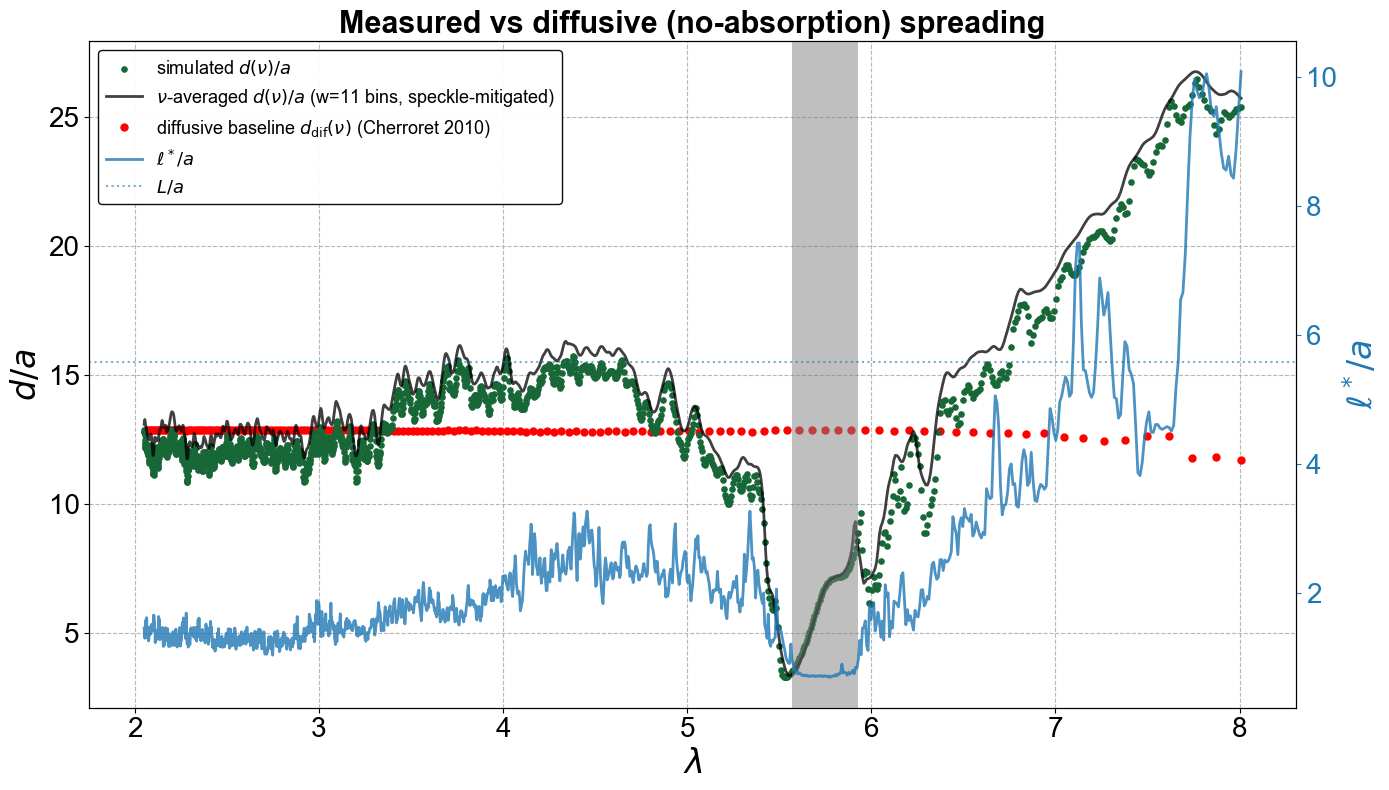

In [51]:
fig, ax = plt.subplots(figsize=(14, 8), dpi=100)

ax.scatter(a/freq, d, s=14, zorder=5, label=r"simulated $d(\nu)/a$")
ax.plot(a/freq, d_avg, lw=2, color="k", alpha=0.75, zorder=6,
        label=rf"$\nu$-averaged $d(\nu)/a$ (w={w_nu} bins, speckle-mitigated)")
ax.plot(a/freq_sampled, (d_diff), "o", ms=5, color='red',
        label=r"diffusive baseline $d_{\rm dif}(\nu)$ (Cherroret 2010)")


ax.axvspan(gaps_ff_22_n_2p90[0], gaps_ff_22_n_2p90[1], facecolor='gray', alpha=0.5, edgecolor='none', zorder=1000, clip_on=False)
ax.set_xlabel(r"$\lambda$", fontsize=24, fontweight='bold')
ax.set_ylabel(r"$d/a$", fontsize=24, fontweight='bold')
ax.grid(True, which="both", alpha=0.9, linestyle='--')
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_title("Measured vs diffusive (no-absorption) spreading", fontsize=22, fontweight='bold')
ax.set_facecolor('white'); fig.patch.set_facecolor('white')
ax2 = ax.twinx()
ax2.plot(a/freq, l_t / a, lw=2, color="tab:blue", alpha=0.8,
         label=r"$\ell^*/a$")
ax2.axhline(L_slab / a, color="tab:blue", ls=":", lw=1.5, alpha=0.6,
            label=r"$L/a$")

ax2.set_ylabel(r"$\ell^*/a$", fontsize=24, fontweight="bold", color="tab:blue")
ax2.tick_params(axis="y", labelsize=20, colors="tab:blue")

handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2,
          loc='best', fontsize=13, framealpha=0.95, edgecolor='black')
plt.tight_layout()
plt.show()

**Reading the plot.**
- **Diffusive band ($\nu\gtrsim0.8$):** the measured $d(\nu)$ tracks the diffusive baseline $d_{\rm dif}$ closely — raw $d$ a median 6 % above it (range −2 % to +15 %; $\nu$‑averaged ≈ +11 %), with $\ell^{*}/L\simeq0.19$–$0.30$, i.e. genuine multiple scattering. The baseline carries **no free fit parameters** (only $L$ and the measured $\ell^{*}(\nu)$), so this agreement is meaningful — but remember it sits on two partially cancelling systematics: the neglected $z_0$ (theory **up** by $\sim4z_0/L$ on $\sigma^2$) and single‑shot speckle (data **down** by ~15 %, mostly removed in the $\nu$‑averaged curve).
- **Band gap (grey, $\nu\simeq0.43$–$0.46$):** $d(\nu)$ plunges to ≈ 4.0 ($\nu$‑avg 3.9) against a flat baseline of ≈ 11.6 — a factor ≈ 3, far outside every systematic: strong **transverse confinement**. Per Cherroret 2010 the width crosses over from $\sigma^{2}\!\sim\!\tfrac23L^{2}$ toward $\sigma^{2}\!\sim\!2L\ell_{\rm att}$; the dip depth measures the **attenuation length** $\ell_{\rm att}$. *Caveat (their pp. 7–8):* a CW measurement cannot distinguish whether $\ell_{\rm att}$ is a localization length $\xi$ or the gap's Bragg/evanescent decay length — absorption-like attenuation produces the *identical* $\sigma^2\simeq2LL_a$. The localization claim is settled by the time‑resolved $\sigma^{2}(t)$ (saturation vs. unbounded growth; absorption‑immune) in the companion FFT notebooks, and by scaling with $L$.
- **Just above the gap ($\nu\approx0.66$–$0.70$):** the data runs ~30–40 % **above** the baseline — band‑edge transport enhancement (and the largest $z_0$/marginal‑$\ell^{*}$ territory), *not* confinement.
- **Low $\nu$ ($\lesssim0.41$):** $\ell^{*}>0.3L$ (blue curve vs the $L/a$ line), so diffusion does not apply — the baseline is deliberately left undefined, and the large measured $d$ there is quasi‑ballistic spreading.

The baseline is *supposed* to be a flat reference, not to follow the data; it is the data's **departure** from it (the gap dip) that is physical. To turn the dip into a quantitative $\ell_{\rm att}(\nu)$ (→ $\xi$ once the time domain confirms localization), invert the measured width against `sigma2_localized_cw(L, xi)`; `sigma2_mobility_edge_cw(L, l_t)` marks the diffuse→localized crossover level.